# Classical RL → Quantum RL on CartPole

## Imports

In [12]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

## Random agent

In [13]:
env = gym.make("CartPole-v1")

print("=== CartPole-v1 Environment ===")
print(f"Observation space : {env.observation_space}")
print(f"Observation shape : {env.observation_space.shape}")
print(f"Action space      : {env.action_space}")
print(f"Action meanings   : 0 = push LEFT | 1 = push RIGHT")
print(f"Max reward/episode: 500")

=== CartPole-v1 Environment ===
Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation shape : (4,)
Action space      : Discrete(2)
Action meanings   : 0 = push LEFT | 1 = push RIGHT
Max reward/episode: 500


### random agent - one episode

In [14]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)

print(f"Initial observation: {obs}\n")

total_reward = 0
step = 0

while True:
    action = env.action_space.sample()       # random action: 0 or 1
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward # type:ignore
    step += 1

    print(f"Step {step:3d} | Action: {action} | Reward: {reward} | Obs: {np.round(obs, 3)}")

    if terminated or truncated:
        print(f"\nEpisode finished after {step} steps | Total reward: {total_reward}")
        break

env.close()

Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Step   1 | Action: 0 | Reward: 1.0 | Obs: [ 0.027 -0.202  0.036  0.324]
Step   2 | Action: 1 | Reward: 1.0 | Obs: [ 0.023 -0.007  0.043  0.042]
Step   3 | Action: 0 | Reward: 1.0 | Obs: [ 0.023 -0.203  0.044  0.348]
Step   4 | Action: 1 | Reward: 1.0 | Obs: [ 0.019 -0.008  0.051  0.07 ]
Step   5 | Action: 1 | Reward: 1.0 | Obs: [ 0.019  0.186  0.052 -0.207]
Step   6 | Action: 1 | Reward: 1.0 | Obs: [ 0.023  0.38   0.048 -0.482]
Step   7 | Action: 1 | Reward: 1.0 | Obs: [ 0.03   0.575  0.038 -0.76 ]
Step   8 | Action: 0 | Reward: 1.0 | Obs: [ 0.042  0.379  0.023 -0.455]
Step   9 | Action: 0 | Reward: 1.0 | Obs: [ 0.049  0.184  0.014 -0.155]
Step  10 | Action: 1 | Reward: 1.0 | Obs: [ 0.053  0.379  0.011 -0.444]
Step  11 | Action: 1 | Reward: 1.0 | Obs: [ 0.061  0.574  0.002 -0.733]
Step  12 | Action: 0 | Reward: 1.0 | Obs: [ 0.072  0.378 -0.013 -0.44 ]
Step  13 | Action: 0 | Reward: 1.0 | Obs: [ 0.08   0.183 -0.022 

### random agent - many episode

In [15]:
env = gym.make("CartPole-v1")
episode_rewards = []
num_episodes = 200

for ep in range(num_episodes):
    obs, info = env.reset()
    total_reward = 0

    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward # type:ignore

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)

env.close()

print(f"Random Agent over {num_episodes} episodes:")
print(f"  Average reward : {np.mean(episode_rewards):.2f}")
print(f"  Max reward     : {np.max(episode_rewards):.2f}")
print(f"  Min reward     : {np.min(episode_rewards):.2f}")

Random Agent over 200 episodes:
  Average reward : 21.99
  Max reward     : 82.00
  Min reward     : 9.00


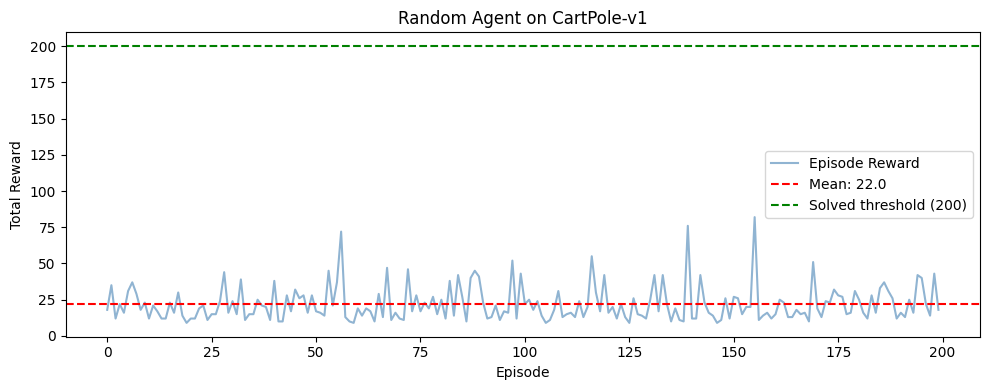

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.6, color='steelblue', label='Episode Reward')
plt.axhline(np.mean(episode_rewards), color='red', linestyle='--', label=f'Mean: {np.mean(episode_rewards):.1f}') # type:ignore
plt.axhline(200, color='green', linestyle='--', label='Solved threshold (200)')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Random Agent on CartPole-v1")
plt.legend()
plt.tight_layout()
plt.show()

### Understand one full step deeply

In [17]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)

print("=== Dissecting the RL loop ===\n")
print(f"STATE  : {obs}")
print(f"         [cart_pos={obs[0]:.3f}, cart_vel={obs[1]:.3f}, pole_angle={obs[2]:.3f}, pole_vel={obs[3]:.3f}]\n")

action = 1  # push right
print(f"ACTION : {action} (push RIGHT)\n")

obs, reward, terminated, truncated, info = env.step(action)

print(f"REWARD     : {reward}  (always 1.0 while pole is up)")
print(f"TERMINATED : {terminated}  (True if pole fell or cart out of bounds)")
print(f"TRUNCATED  : {truncated}  (True if 500 steps reached)")
print(f"NEW STATE  : {obs}")
print(f"             [cart_pos={obs[0]:.3f}, cart_vel={obs[1]:.3f}, pole_angle={obs[2]:.3f}, pole_vel={obs[3]:.3f}]")

env.close()

=== Dissecting the RL loop ===

STATE  : [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
         [cart_pos=0.014, cart_vel=-0.023, pole_angle=-0.046, pole_vel=-0.048]

ACTION : 1 (push RIGHT)

REWARD     : 1.0  (always 1.0 while pole is up)
TERMINATED : False  (True if pole fell or cart out of bounds)
TRUNCATED  : False  (True if 500 steps reached)
NEW STATE  : [ 0.01323574  0.17272775 -0.04686959 -0.3551522 ]
             [cart_pos=0.013, cart_vel=0.173, pole_angle=-0.047, pole_vel=-0.355]


### RL loop

In [18]:
print("""
╔══════════════════════════════════════════════════════╗
║              THE RL LOOP — CartPole                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║   ┌─────────┐    state s      ┌─────────┐            ║
║   │         │ ─────────────▶ │         │            ║
║   │  ENV    │                 │  AGENT  │            ║
║   │CartPole │ ◀───────────── │         │            ║
║   │         │    action a     │         │            ║
║   └─────────┘                 └─────────┘            ║
║        │                                             ║
║        │  reward r, next state s'                    ║
║        ▼                                             ║
║   Goal: maximize cumulative reward                   ║
║   Solved when avg reward ≥ 200 over 100 episodes     ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")

print("State  s  → 4 floats (what the agent sees)")
print("Action a  → 0 or 1  (what the agent does)")
print("Reward r  → 1.0     (feedback from environment)")
print("           adds up over episode → episode reward")


╔══════════════════════════════════════════════════════╗
║              THE RL LOOP — CartPole                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║   ┌─────────┐    state s      ┌─────────┐            ║
║   │         │ ─────────────▶ │         │            ║
║   │  ENV    │                 │  AGENT  │            ║
║   │CartPole │ ◀───────────── │         │            ║
║   │         │    action a     │         │            ║
║   └─────────┘                 └─────────┘            ║
║        │                                             ║
║        │  reward r, next state s'                    ║
║        ▼                                             ║
║   Goal: maximize cumulative reward                   ║
║   Solved when avg reward ≥ 200 over 100 episodes     ║
║                                                      ║
╚══════════════════════════════════════════════════════╝

State  s  → 4 floats (what the 

## DQN

### Import

In [37]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import random

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


### Network

In [38]:
# Cell 2 - Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    
    def forward(self, x):
        return self.net(x)

# Quick test — push to device
net         = QNetwork(state_dim=4, action_dim=2).to(device)
dummy_state = torch.FloatTensor([0.1, 0.2, -0.1, 0.05]).to(device)
q_values    = net(dummy_state)
print(f"Network on : {next(net.parameters()).device}")
print(f"Q-values   : {q_values.detach().cpu().numpy()}")

Network on : cuda:0
Q-values   : [ 0.04165706 -0.0422016 ]


### replay buffer

In [39]:
# Cell 3 - Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        
        # Push directly to device here
        states      = torch.FloatTensor(np.array([e[0] for e in batch])).to(device)
        actions     = torch.LongTensor(np.array([e[1] for e in batch])).to(device)
        rewards     = torch.FloatTensor(np.array([e[2] for e in batch])).to(device)
        next_states = torch.FloatTensor(np.array([e[3] for e in batch])).to(device)
        dones       = torch.FloatTensor(np.array([e[4] for e in batch])).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

### DQN agent

In [40]:
# Cell 4 - DQN Agent
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        # Push both networks to device
        self.online_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=1e-3)
        self.buffer    = ReplayBuffer(capacity=10000)
        
        self.gamma      = 0.99
        self.epsilon    = 1.0
        self.eps_min    = 0.01
        self.eps_decay  = 0.995
        self.batch_size = 64
        self.update_target_every = 100
        self.step_count = 0
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        # Push state to device
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_tensor)
        return q_values.argmax().item()
    
    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        current_q = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q   = rewards + self.gamma * max_next_q * (1 - dones)
        
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        
        self.step_count += 1
        if self.step_count % self.update_target_every == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        
        return loss.item()

print(f"DQNAgent ready on {device}")

DQNAgent ready on cuda


### training loop

In [41]:
env   = gym.make("CartPole-v1")
agent = DQNAgent(state_dim=4, action_dim=2)

episode_rewards_clasical = []
losses          = []
num_episodes    = 200

print(f"Training for {num_episodes} episodes...\n")

for ep in tqdm(range(num_episodes), desc="Training"):
    obs, _ = env.reset()
    total_reward = 0

    while True:
        action               = agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done                 = terminated or truncated
        
        # Store experience in replay buffer
        agent.buffer.push(obs, action, reward, next_obs, float(done))
        
        # Learn from experience
        loss = agent.learn()
        if loss:
            losses.append(loss)
        
        obs           = next_obs
        total_reward += reward # type:ignore
        
        if done:
            break
    
    episode_rewards_clasical.append(total_reward)
    
    # Print progress every 50 episodes
    if (ep + 1) % 50 == 0:
        avg = np.mean(episode_rewards[-50:])
        print(f"Episode {ep+1:4d} | Avg Reward (last 50): {avg:6.1f} | Epsilon: {agent.epsilon:.3f}")

env.close()
print("\nTraining complete.")

Training for 200 episodes...



Training:   0%|          | 0/200 [00:00<?, ?it/s]

Episode   50 | Avg Reward (last 50):  471.8 | Epsilon: 0.010
Episode  100 | Avg Reward (last 50):  471.8 | Epsilon: 0.010
Episode  150 | Avg Reward (last 50):  471.8 | Epsilon: 0.010
Episode  200 | Avg Reward (last 50):  471.8 | Epsilon: 0.010

Training complete.


### plot

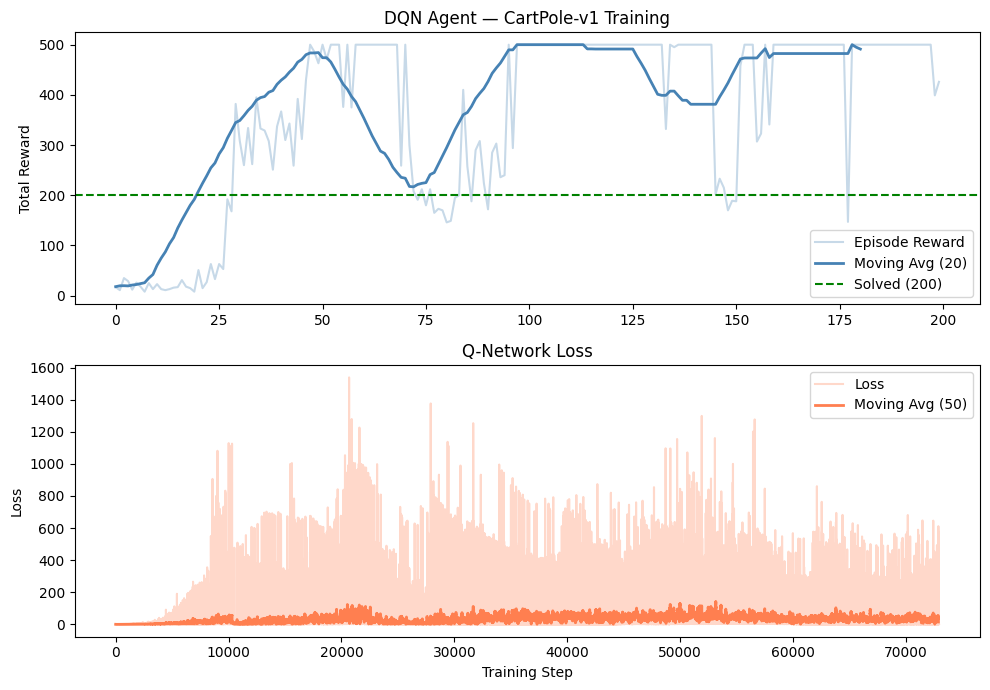

Final avg reward (last 100 episodes): 469.2


In [ ]:
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Reward plot
ax1.plot(episode_rewards_clasical, alpha=0.3, color='steelblue', label='Episode Reward')
ax1.plot(moving_average(episode_rewards_clasical, 20), color='steelblue', linewidth=2, label='Moving Avg (20)')
ax1.axhline(200, color='green', linestyle='--', linewidth=1.5, label='Solved (200)')
ax1.set_ylabel("Total Reward")
ax1.set_title("DQN Agent — CartPole-v1 Training")
ax1.legend()

# Loss plot
ax2.plot(losses, alpha=0.3, color='coral', label='Loss')
ax2.plot(moving_average(losses, 50), color='coral', linewidth=2, label='Moving Avg (50)')
ax2.set_xlabel("Training Step")
ax2.set_ylabel("Loss")
ax2.set_title("Q-Network Loss")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final avg reward (last 100 episodes): {np.mean(episode_rewards_clasical[-100:]):.1f}")

### visual

In [25]:
env   = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)

total_reward = 0
step         = 0
agent.epsilon = 0.0  # no exploration — pure policy

print("Watching trained agent...\n")
print(f"{'Step':>5} | {'Action':>8} | {'Cart Pos':>10} | {'Pole Angle':>10} | {'Reward':>8}")
print("-" * 55)

while True:
    action = agent.select_action(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward # type:ignore
    step         += 1
    
    direction = "RIGHT" if action == 1 else "LEFT "
    print(f"{step:>5} | {direction:>8} | {obs[0]:>10.3f} | {obs[2]:>10.4f} | {reward:>8.1f}")
    
    if terminated or truncated:
        break

env.close()
print(f"\nTotal steps survived: {step} | Total reward: {total_reward}")

Watching trained agent...

 Step |   Action |   Cart Pos | Pole Angle |   Reward
-------------------------------------------------------
    1 |    RIGHT |      0.027 |     0.0363 |      1.0
    2 |    LEFT  |      0.031 |     0.0310 |      1.0
    3 |    RIGHT |      0.031 |     0.0319 |      1.0
    4 |    LEFT  |      0.035 |     0.0271 |      1.0
    5 |    RIGHT |      0.034 |     0.0283 |      1.0
    6 |    LEFT  |      0.038 |     0.0239 |      1.0
    7 |    RIGHT |      0.038 |     0.0255 |      1.0
    8 |    LEFT  |      0.042 |     0.0214 |      1.0
    9 |    RIGHT |      0.042 |     0.0233 |      1.0
   10 |    LEFT  |      0.045 |     0.0195 |      1.0
   11 |    RIGHT |      0.045 |     0.0217 |      1.0
   12 |    LEFT  |      0.049 |     0.0181 |      1.0
   13 |    RIGHT |      0.049 |     0.0206 |      1.0
   14 |    LEFT  |      0.052 |     0.0173 |      1.0
   15 |    RIGHT |      0.052 |     0.0200 |      1.0
   16 |    LEFT  |      0.056 |     0.0169 |      1.0

## VQC

### Import

In [26]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


### VQC model

In [27]:
n_qubits = 4   # one qubit per state dimension
n_layers = 3   # variational layers (depth)

# Create a quantum device (simulator running on your CPU)
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    inputs  : 4 floats (the state from CartPole)
    weights : trainable parameters (shape: n_layers × n_qubits × 2)
    returns : 2 expectation values → Q(s,LEFT), Q(s,RIGHT)
    """
    
    # --- Encoding layer ---
    # Embed classical state into qubit rotation angles
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RY(inputs[i], wires=i)
    
    # --- Variational layers ---
    for layer in range(n_layers):
        # Parameterized rotations on each qubit
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        
        # Entanglement — connects qubits so they share information
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])  # wrap around
    
    # --- Measurement ---
    # Returns expectation value of Z on first 2 qubits → 2 Q-values
    return [qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1))]

# Visualize the circuit
dummy_input   = torch.zeros(n_qubits)
dummy_weights = torch.zeros(n_layers, n_qubits, 2)
print(qml.draw(quantum_circuit)(dummy_input, dummy_weights))

0: ──H──RY(0.00)──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00) ···
1: ──H──RY(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00) ···
2: ──H──RY(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00) ···
3: ──H──RY(0.00)──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00) ···

0: ··· ──RZ(0.00)─╭●───────╭X─┤  <Z>
1: ··· ──RZ(0.00)─╰X─╭●────│──┤  <Z>
2: ··· ──RZ(0.00)────╰X─╭●─│──┤     
3: ··· ──RZ(0.00)───────╰X─╰●─┤     


### nn network

In [28]:
# This makes it plug directly into the DQN framework
# replacing QNetwork with zero other changes

class VQCQNetwork(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super(VQCQNetwork, self).__init__()
        
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
        # Trainable parameters — equivalent to neural net weights
        # Shape: (n_layers, n_qubits, 2) → 2 rotations per qubit per layer
        self.weights = nn.Parameter(
            torch.randn(n_layers, n_qubits, 2) * 0.1
        )
        
        # Input scaling — learned rescaling of state values
        # State values can be large; this keeps them in a good angle range
        self.input_scaling = nn.Parameter(torch.ones(n_qubits))
        
        # self.output_scaling = nn.Parameter(torch.ones(2) * 50.0)
        self.output_scaling = 50
    
    def forward(self, x):
        # x shape: (batch_size, 4) or (4,)
        # VQC processes one sample at a time
        
        if x.dim() == 1:
            # Single state
            scaled = x * self.input_scaling
            output = quantum_circuit(scaled, self.weights)
            return torch.stack(output) * self.output_scaling 
        else:
            # Batch — process each sample and stack results
            results = []
            for sample in x:
                scaled = sample * self.input_scaling
                out    = quantum_circuit(scaled, self.weights)
                results.append(torch.stack(out) * self.output_scaling)
            return torch.stack(results)

# Test it
vqc_net     = VQCQNetwork(n_qubits, n_layers)
dummy_state = torch.FloatTensor([0.1, 0.2, -0.1, 0.05])
q_vals      = vqc_net(dummy_state)
print(f"Input state : {dummy_state.numpy()}")
print(f"Q-values    : {q_vals.detach().numpy()}")
print(f"Best action : {'RIGHT' if q_vals.argmax().item() == 1 else 'LEFT'}")
print(f"\nTrainable parameters: {sum(p.numel() for p in vqc_net.parameters())}")

Input state : [ 0.1   0.2  -0.1   0.05]
Q-values    : [-17.88057893  -1.77659056]
Best action : RIGHT

Trainable parameters: 28


### buffer

In [29]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch       = random.sample(self.buffer, batch_size)
        states      = torch.FloatTensor(np.array([e[0] for e in batch]))
        actions     = torch.LongTensor(np.array([e[1] for e in batch]))
        rewards     = torch.FloatTensor(np.array([e[2] for e in batch]))
        next_states = torch.FloatTensor(np.array([e[3] for e in batch]))
        dones       = torch.FloatTensor(np.array([e[4] for e in batch]))
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

### agent

In [30]:
# Identical structure to Phase 2 — only the network changed

class QuantumDQNAgent:
    def __init__(self, n_qubits, n_layers, action_dim):
        self.action_dim = action_dim
        
        # VQC instead of QNetwork — everything else identical
        self.online_net = VQCQNetwork(n_qubits, n_layers)
        self.target_net = VQCQNetwork(n_qubits, n_layers)
        self.target_net.load_state_dict(self.online_net.state_dict())
        
        # Same optimizer as Phase 2
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=1e-3)
        self.buffer    = ReplayBuffer(capacity=10000)
        
        self.gamma      = 0.99
        self.epsilon    = 1.0
        self.eps_min    = 0.01
        self.eps_decay  = 0.99
        self.batch_size = 16    # smaller than Phase 2 — VQC is slower to evaluate
        self.update_target_every = 50
        self.step_count = 0
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            q_values     = self.online_net(state_tensor)
        return q_values.argmax().item()
    
    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        current_q = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q   = rewards + self.gamma * max_next_q * (1 - dones)
        
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=1.0)  # ADD THIS
        self.optimizer.step()
        
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        
        self.step_count += 1
        if self.step_count % self.update_target_every == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        
        return loss.item()

print("QuantumDQNAgent ready")

QuantumDQNAgent ready


### training loop

In [31]:
# Identical to Phase 2 — the loop doesn't know or care what's inside the agent

env   = gym.make("CartPole-v1")
agent = QuantumDQNAgent(n_qubits=4, n_layers=3, action_dim=2)

quantum_rewards = []
quantum_losses  = []
num_episodes    = 100  # fewer episodes — VQC training is slower

print(f"Training Quantum DQN for {num_episodes} episodes...")
print("(expect this to be slower than Phase 2 — circuit simulation has overhead)\n")

for ep in tqdm(range(num_episodes), desc="Quantum Training"):
    obs, _       = env.reset()
    total_reward = 0
    
    while True:
        action                               = agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        agent.buffer.push(obs, action, reward, next_obs, float(done))
        loss = agent.learn()
        if loss:
            quantum_losses.append(loss)
        
        obs           = next_obs
        total_reward += reward # type:ignore
        
        if done:
            break
    
    quantum_rewards.append(total_reward)
    
    if (ep + 1) % 10 == 0:
        avg = np.mean(quantum_rewards[-25:])
        print(f"Episode {ep+1:4d} | Avg Reward (last 25): {avg:6.1f} | Epsilon: {agent.epsilon:.3f}")

env.close()
print("\nQuantum training complete.")

Training Quantum DQN for 100 episodes...
(expect this to be slower than Phase 2 — circuit simulation has overhead)



Quantum Training:   0%|          | 0/100 [00:00<?, ?it/s]

Episode   10 | Avg Reward (last 25):   12.7 | Epsilon: 0.324
Episode   20 | Avg Reward (last 25):   11.3 | Epsilon: 0.119
Episode   30 | Avg Reward (last 25):   10.2 | Epsilon: 0.044
Episode   40 | Avg Reward (last 25):    9.4 | Epsilon: 0.018
Episode   50 | Avg Reward (last 25):    9.4 | Epsilon: 0.010
Episode   60 | Avg Reward (last 25):   10.2 | Epsilon: 0.010
Episode   70 | Avg Reward (last 25):   14.6 | Epsilon: 0.010
Episode   80 | Avg Reward (last 25):   18.6 | Epsilon: 0.010
Episode   90 | Avg Reward (last 25):   18.9 | Epsilon: 0.010
Episode  100 | Avg Reward (last 25):   19.8 | Epsilon: 0.010

Quantum training complete.


### compare

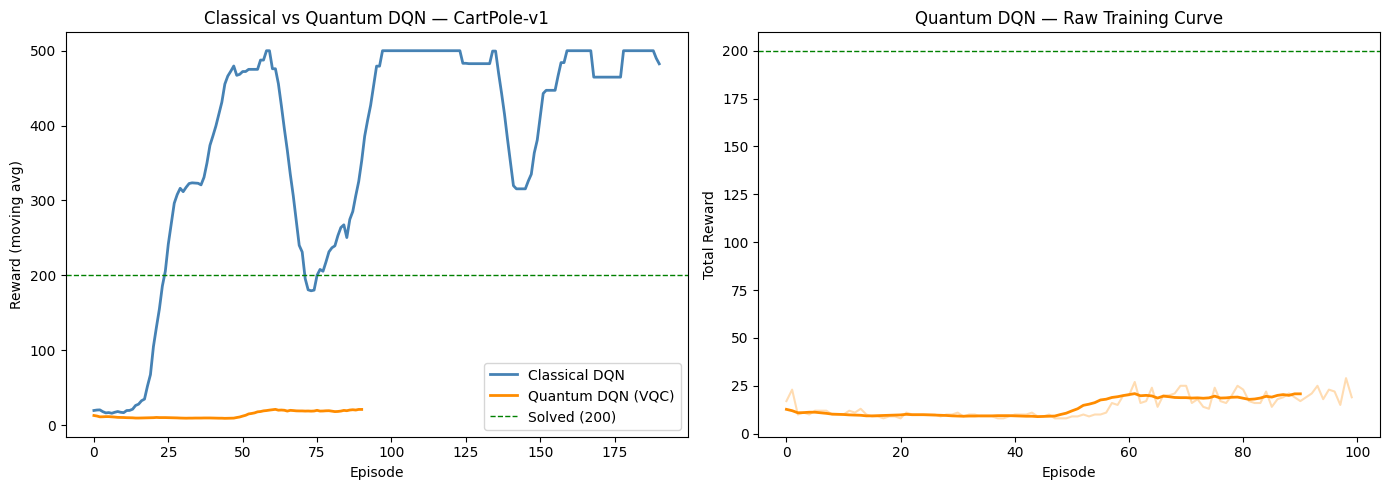

Classical DQN | Avg last 100 eps : 469.2
Quantum DQN   | Avg last 100 eps : 14.1


In [32]:
# Load classical rewards from Phase 2
# (make sure episode_rewards from Phase 2 is still in memory)

def moving_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: head to head ---
ax = axes[0]

# Classical (Phase 2) — only plot first 200 episodes for fair comparison
classical_trimmed = episode_rewards[:200]
ax.plot(moving_average(classical_trimmed, 10), 
        color='steelblue', linewidth=2, label='Classical DQN')
ax.plot(moving_average(quantum_rewards, 10),   
        color='darkorange', linewidth=2, label='Quantum DQN (VQC)')
ax.axhline(200, color='green', linestyle='--', linewidth=1, label='Solved (200)')
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (moving avg)")
ax.set_title("Classical vs Quantum DQN — CartPole-v1")
ax.legend()

# --- Right plot: raw quantum rewards ---
ax2 = axes[1]
ax2.plot(quantum_rewards, alpha=0.3, color='darkorange')
ax2.plot(moving_average(quantum_rewards, 10), color='darkorange', linewidth=2)
ax2.axhline(200, color='green', linestyle='--', linewidth=1)
ax2.set_xlabel("Episode")
ax2.set_ylabel("Total Reward")
ax2.set_title("Quantum DQN — Raw Training Curve")

plt.tight_layout()
plt.show()

print(f"Classical DQN | Avg last 100 eps : {np.mean(episode_rewards[-100:]):.1f}")
print(f"Quantum DQN   | Avg last 100 eps : {np.mean(quantum_rewards[-100:]):.1f}")

In [33]:
# Diagnostic Cell - Check gradient magnitudes
agent_test = QuantumDQNAgent(n_qubits=4, n_layers=2, action_dim=2)

# Fill buffer with some random experience
env = gym.make("CartPole-v1")
obs, _ = env.reset()
for _ in range(50):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    agent_test.buffer.push(obs, action, reward, next_obs, float(terminated or truncated))
    obs = next_obs
    if terminated or truncated:
        obs, _ = env.reset()
env.close()

# Run one learning step and inspect gradients
agent_test.learn()

print("Gradient magnitudes after one learn() step:\n")
for name, param in agent_test.online_net.named_parameters():
    if param.grad is not None:
        print(f"{name:20s} | grad norm: {param.grad.norm().item():.8f} | param values: {param.data.flatten()[:4].numpy()}")
    else:
        print(f"{name:20s} | grad is None")

IndexError: index 2 is out of bounds for dimension 0 with size 2

# Softmax-PQC 

## import

In [51]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Curcuit architecture

In [52]:
# Architecture: H → Uvar(φ0) → CZ → Uenc(s,λ) → Uvar(φ1) → Measure
# Faithful to Skolik et al. Figure 2

n_qubits = 4    # one per state dimension
n_layers  = 1   # Denc=1 for CartPole (as in paper)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="parameter-shift")
def softmax_pqc_circuit(inputs, var_weights, enc_weights):
    """
    inputs      : state s (4 floats)
    var_weights : variational params φ shape (n_layers+1, n_qubits, 2)
                  one extra Uvar block because structure is:
                  Uvar(φ0) → Uenc → Uvar(φ1) → ... → Uvar(φ_last)
    enc_weights : encoding scaling λ shape (n_layers, n_qubits)
                  trainable per-qubit scaling of state values
    returns     : expectation values ⟨Z⟩ for each qubit
    """

    # --- Step 1: Hadamard on all qubits ---
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # --- Step 2: Alternating Uvar → CZ → Uenc blocks ---
    for layer in range(n_layers):

        # Uvar block (variational rotations)
        for i in range(n_qubits):
            qml.RZ(var_weights[layer, i, 0], wires=i)
            qml.RY(var_weights[layer, i, 1], wires=i)

        # Entanglement: CZ gates (both controls filled = CZ not CNOT)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i + 1])
        qml.CZ(wires=[n_qubits - 1, 0])  # wrap around

        # Uenc block: encode state with trainable scaling λ
        for i in range(n_qubits):
            qml.RY(enc_weights[layer, i] * inputs[i], wires=i)
            qml.RZ(enc_weights[layer, i] * inputs[i], wires=i)

    # --- Step 3: Final Uvar block (always one more than Uenc) ---
    for i in range(n_qubits):
        qml.RZ(var_weights[n_layers, i, 0], wires=i)
        qml.RY(var_weights[n_layers, i, 1], wires=i)

    # --- Step 4: Measurement ---
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Visualize
dummy_input   = torch.zeros(n_qubits)
dummy_var     = torch.zeros(n_layers + 1, n_qubits, 2)
dummy_enc     = torch.ones(n_layers, n_qubits)
print(qml.draw(softmax_pqc_circuit)(dummy_input, dummy_var, dummy_enc))

0: ──H──RZ(0.00)──RY(0.00)─╭●───────╭Z──RY(0.00)──RZ(0.00)──RZ(0.00)──RY(0.00)─┤  <Z>
1: ──H──RZ(0.00)──RY(0.00)─╰Z─╭●────│───RY(0.00)──RZ(0.00)──RZ(0.00)──RY(0.00)─┤  <Z>
2: ──H──RZ(0.00)──RY(0.00)────╰Z─╭●─│───RY(0.00)──RZ(0.00)──RZ(0.00)──RY(0.00)─┤  <Z>
3: ──H──RZ(0.00)──RY(0.00)───────╰Z─╰●──RY(0.00)──RZ(0.00)──RZ(0.00)──RY(0.00)─┤  <Z>


## Softmax-pqc network

In [53]:
# Key additions vs Phase 3:
# → trainable encoding scaling λ (enc_weights)
# → trainable output scaling β (beta)
# → softmax output → action probabilities instead of Q-values

class SoftmaxPQC(nn.Module):
    def __init__(self, n_qubits, n_layers, n_actions):
        super(SoftmaxPQC, self).__init__()

        self.n_qubits  = n_qubits
        self.n_layers  = n_layers
        self.n_actions = n_actions

        # Variational parameters φ: (n_layers+1) blocks × n_qubits × 2 rotations
        self.var_weights = nn.Parameter(
            torch.randn(n_layers + 1, n_qubits, 2) * 0.01
        )

        # Encoding scaling λ: learned per qubit per encoding layer
        self.enc_weights = nn.Parameter(
            torch.ones(n_layers, n_qubits)
        )

        # Output scaling β: "trainable greediness"
        # One weight per action — maps qubit measurements to action logits
        # n_actions=2, n_qubits=4 → we use first 2 qubits for actions
        self.beta = nn.Parameter(
            torch.ones(n_actions) * 0.5
        )

    def forward(self, x):
        """
        x: state tensor (4,) or (batch, 4)
        returns: action probabilities via softmax
        """
        if x.dim() == 1:
            # Single state
            measurements = softmax_pqc_circuit(x, self.var_weights, self.enc_weights)
            measurements = torch.stack(measurements)

            # Use first n_actions qubits as action logits
            logits = measurements[:self.n_actions] * self.beta

            return torch.softmax(logits, dim=0)
        else:
            # Batch
            results = []
            for sample in x:
                measurements = softmax_pqc_circuit(sample, self.var_weights, self.enc_weights)
                measurements = torch.stack(measurements)
                logits       = measurements[:self.n_actions] * self.beta
                results.append(torch.softmax(logits, dim=0))
            return torch.stack(results)

# Test
net         = SoftmaxPQC(n_qubits=4, n_layers=1, n_actions=2)
dummy_state = torch.FloatTensor([0.1, 0.2, -0.1, 0.05])
probs       = net(dummy_state)
print(f"Action probabilities : {probs.detach().numpy()}")
print(f"Sum (should be 1.0)  : {probs.sum().item():.6f}")
print(f"Trainable parameters : {sum(p.numel() for p in net.parameters())}")

Action probabilities : [0.49802294 0.50197706]
Sum (should be 1.0)  : 1.000000
Trainable parameters : 22


## value function

In [54]:
# Small classical MLP that estimates expected return from a state
# Reduces variance in REINFORCE gradient estimates
# This is purely classical — no quantum component

class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super(ValueNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   # single scalar: expected return
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Test
vnet        = ValueNetwork(state_dim=4)
dummy_state = torch.FloatTensor([0.1, 0.2, -0.1, 0.05])
value       = vnet(dummy_state)
print(f"Estimated value: {value.item():.4f}")

Estimated value: -0.0004


## reinforce agent

In [55]:
# Key differences from Phase 3 DQN:
# → no replay buffer (on-policy: learns from current episodes only)
# → collects full episodes before updating
# → policy gradient instead of Bellman equation
# → value baseline to reduce variance

class REINFORCEAgent:
    def __init__(self, n_qubits, n_layers, n_actions, state_dim):

        # Quantum policy network
        self.policy = SoftmaxPQC(n_qubits, n_layers, n_actions)

        # Classical value baseline
        self.value_net = ValueNetwork(state_dim)

        # Separate optimizers — policy needs lower lr (quantum params sensitive)
        self.policy_optimizer = optim.Adam(self.policy.parameters(),     lr=0.01)
        self.value_optimizer  = optim.Adam(self.value_net.parameters(),  lr=0.001)

        self.gamma    = 0.99
        self.n_actions = n_actions

        # Episode storage — no replay buffer, store current episode only
        self.states   = []
        self.actions  = []
        self.rewards  = []
        self.log_probs = []

    def select_action(self, state):
        state_tensor = torch.FloatTensor(state)

        # Get action probabilities from circuit
        probs  = self.policy(state_tensor)

        # Sample action from distribution (not argmax — policy gradient needs sampling)
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()

        # Store log probability for gradient computation
        self.log_probs.append(dist.log_prob(action))
        self.states.append(state_tensor)
        self.actions.append(action)

        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def compute_returns(self):
        """Compute discounted returns G_t for each timestep"""
        returns = []
        G = 0
        # Traverse backwards through episode
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)

        # Normalize returns — reduces variance significantly
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        return returns

    def update(self):
        """REINFORCE update with value baseline"""
        returns      = self.compute_returns()
        states       = torch.stack(self.states)
        log_probs    = torch.stack(self.log_probs)

        # Value baseline: what did we expect from each state?
        values       = self.value_net(states).detach()

        # Advantage: was this return better or worse than expected?
        advantages   = returns - values

        # Policy gradient loss (negative because we do gradient ASCENT on reward)
        policy_loss  = -(log_probs * advantages).mean()

        # Value loss: train baseline to better predict returns
        value_preds  = self.value_net(states)
        value_loss   = nn.MSELoss()(value_preds, returns)

        # Update policy (quantum circuit parameters)
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=1.0)
        self.policy_optimizer.step()

        # Update value network (classical)
        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()

        # Clear episode storage
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []

        return policy_loss.item(), value_loss.item()

print("REINFORCEAgent ready")

REINFORCEAgent ready


## training loop

In [56]:
# Cell 6 - Training Loop
env   = gym.make("CartPole-v1")
agent = REINFORCEAgent(n_qubits=4, n_layers=1, n_actions=2, state_dim=4)

episode_rewards = []
policy_losses   = []
value_losses    = []
num_episodes    = 300

print(f"Training Softmax-PQC (REINFORCE) for {num_episodes} episodes...")
print("(parameter-shift rule: slower than backprop but hardware compatible)\n")

for ep in tqdm(range(num_episodes), desc="Softmax-PQC Training"):
    obs, _       = env.reset()
    total_reward = 0

    while True:
        action               = agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done                 = terminated or truncated

        agent.store_reward(reward)

        obs           = next_obs
        total_reward += reward # type: ignore

        if done:
            break

    # Update after full episode (REINFORCE is on-policy)
    p_loss, v_loss = agent.update()
    policy_losses.append(p_loss)
    value_losses.append(v_loss)
    episode_rewards.append(total_reward)

    if (ep + 1) % 25 == 0:
        avg = np.mean(episode_rewards[-25:])
        print(f"Episode {ep+1:4d} | Avg Reward (last 25): {avg:6.1f} | Policy Loss: {p_loss:.4f}")

env.close()
print("\nSoftmax-PQC training complete.")

Training Softmax-PQC (REINFORCE) for 300 episodes...
(parameter-shift rule: slower than backprop but hardware compatible)



Softmax-PQC Training:   0%|          | 0/300 [00:00<?, ?it/s]

Episode   25 | Avg Reward (last 25):   20.4 | Policy Loss: 0.0440
Episode   50 | Avg Reward (last 25):   21.2 | Policy Loss: 0.0628
Episode   75 | Avg Reward (last 25):   23.0 | Policy Loss: 0.0402
Episode  100 | Avg Reward (last 25):   23.0 | Policy Loss: 0.0753
Episode  125 | Avg Reward (last 25):   20.9 | Policy Loss: -0.0325
Episode  150 | Avg Reward (last 25):   23.4 | Policy Loss: -0.0661
Episode  175 | Avg Reward (last 25):   27.0 | Policy Loss: 0.0342
Episode  200 | Avg Reward (last 25):   20.7 | Policy Loss: 0.1993
Episode  225 | Avg Reward (last 25):   24.3 | Policy Loss: -0.0546
Episode  250 | Avg Reward (last 25):   27.8 | Policy Loss: -0.1374
Episode  275 | Avg Reward (last 25):   25.1 | Policy Loss: 0.1537
Episode  300 | Avg Reward (last 25):   23.5 | Policy Loss: -0.1375

Softmax-PQC training complete.


## full comparison

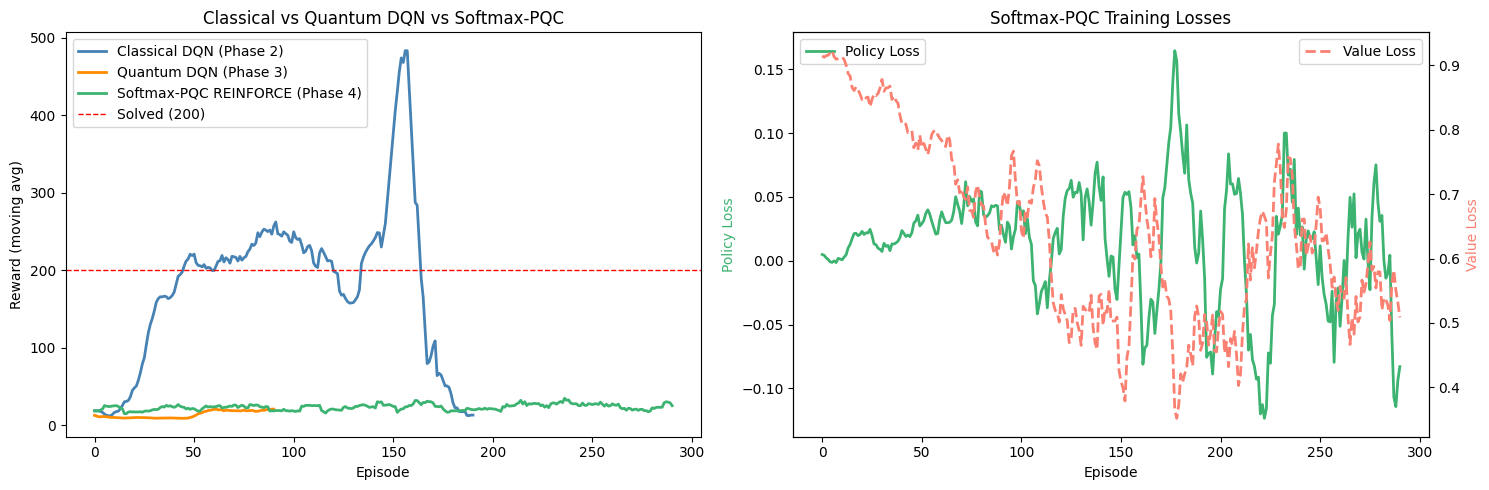

Classical DQN    | Avg last 100 eps : 191.4
Quantum DQN      | Avg last 100 eps : 14.1
Softmax-PQC      | Avg last 100 eps : 25.2


In [57]:
# Classical DQN vs Quantum DQN (Phase 3) vs Softmax-PQC (Phase 4)

def moving_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: three-way comparison ---
ax = axes[0]
ax.plot(moving_average(episode_rewards_clasical[:200], 10),
        color='steelblue', linewidth=2, label='Classical DQN (Phase 2)')
ax.plot(moving_average(quantum_rewards[:200], 10),
        color='darkorange', linewidth=2, label='Quantum DQN (Phase 3)')
ax.plot(moving_average(episode_rewards, 10),
        color='mediumseagreen', linewidth=2, label='Softmax-PQC REINFORCE (Phase 4)')
ax.axhline(200, color='red', linestyle='--', linewidth=1, label='Solved (200)')
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (moving avg)")
ax.set_title("Classical vs Quantum DQN vs Softmax-PQC")
ax.legend()

# --- Right: Softmax-PQC losses ---
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(moving_average(policy_losses, 10),
         color='mediumseagreen', linewidth=2, label='Policy Loss')
ax2_twin.plot(moving_average(value_losses, 10),
              color='salmon', linewidth=2, linestyle='--', label='Value Loss')
ax2.set_xlabel("Episode")
ax2.set_ylabel("Policy Loss", color='mediumseagreen')
ax2_twin.set_ylabel("Value Loss", color='salmon')
ax2.set_title("Softmax-PQC Training Losses")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Classical DQN    | Avg last 100 eps : {np.mean(episode_rewards_clasical[-100:]):.1f}")
print(f"Quantum DQN      | Avg last 100 eps : {np.mean(quantum_rewards[-100:]):.1f}")
print(f"Softmax-PQC      | Avg last 100 eps : {np.mean(episode_rewards[-100:]):.1f}")